In [1]:
pip install memorywrap

In [3]:
%pip install torch torchvision torchaudio
%pip install absl-py
%pip install captum
%pip install pyyaml
%pip install entmax
%pip install einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 26.9 MB/s eta 0:00:00


In [4]:
def checking(pkg_name):
    try:
        mod = __import__(pkg_name)
        print(pkg_name + ":", getattr(mod, "__version__", "no __version__ attr"))
    except ImportError:
        print(pkg_name + ": not installed")

checking("torch")
checking("captum")
checking("yaml")
checking("entmax")
checking("scipy")
checking("einops")

!pip show absl-py

torch: 2.11.0+cpu
captum: 0.9.0
yaml: 6.0.3
entmax: 1.3
scipy: 1.16.3
einops: 0.8.2
Name: absl-py
Version: 1.4.0
Summary: Abseil Python Common Libraries, see https://github.com/abseil/abseil-py.
Home-page: https://github.com/abseil/abseil-py
Author: The Abseil Authors
Author-email: 
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: array_record, dm-tree, dopamine_rl, grain, keras, keras-hub, optax, orbax-checkpoint, tensorboard, tensorflow, tensorflow-datasets, tensorflow-metadata, tensorflow-probability, tf-slim, ydf


In [5]:
### all packages successfully downloaded

In [6]:
!pip install memorywrap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from memorywrap import MemoryWrapLayer, BaselineMemory
seed = 0

In [7]:
class Block(nn.Module):
    '''expand + depthwise + pointwise'''
    def __init__(self, in_planes, out_planes, expansion, stride):
        super(Block, self).__init__()
        self.stride = stride

        planes = expansion * in_planes
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, groups=planes, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, out_planes, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(out_planes)

        self.shortcut = nn.Sequential()
        if stride == 1 and in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(out_planes),
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out + self.shortcut(x) if self.stride==1 else out
        return out

class MobileNetV2(nn.Module):
    # (expansion, out_planes, num_blocks, stride)
    cfg = [(1,  16, 1, 1),
           (6,  24, 2, 1),
           (6,  32, 3, 2),
           (6,  64, 4, 2),
           (6,  96, 3, 1),
           (6, 160, 3, 2),
           (6, 320, 1, 1)]

    def __init__(self, num_classes=10):
        super(MobileNetV2, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.layers = self._make_layers(in_planes=32)
        self.conv2 = nn.Conv2d(320, 1280, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(1280)
        self.mw = MemoryWrapLayer(encoder_output_dim=1280, output_dim=num_classes)

    def _make_layers(self, in_planes):
        layers = []
        for expansion, out_planes, num_blocks, stride in self.cfg:
            strides = [stride] + [1]*(num_blocks-1)
            for stride in strides:
                layers.append(Block(in_planes, out_planes, expansion, stride))
                in_planes = out_planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layers(out)
        out = F.relu(self.bn2(self.conv2(out)))
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)

        return out

    def forward(self, x, mss, return_weights=False):

        # inputs
        out = self.forward_encoder(x)
        out_mss = self.forward_encoder(mss)

        # prediction
        out_mw = self.mw(out,out_mss,return_weights)
        return out_mw

### merging the modification

class MemoryWrapMobileNetV2(nn.Module):
    # (expansion, out_planes, num_blocks, stride)
    cfg = [(1,  16, 1, 1),
           (6,  24, 2, 1),  # NOTE: change stride 2 -> 1 for CIFAR10
           (6,  32, 3, 2),
           (6,  64, 4, 2),
           (6,  96, 3, 1),
           (6, 160, 3, 2),
           (6, 320, 1, 1)]

    def __init__(self, num_classes=10):
        super(MemoryWrapMobileNetV2, self).__init__()
        # NOTE: change conv1 stride 2 -> 1 for CIFAR10
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.layers = self._make_layers(in_planes=32)
        self.conv2 = nn.Conv2d(320, 1280, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(1280)

        #replaced last layer
        #self.linear = nn.Linear(1280, num_classes)
        self.mw = MemoryWrapLayer(1280,num_classes)

    def _make_layers(self, in_planes):
        layers = []
        for expansion, out_planes, num_blocks, stride in self.cfg:
            strides = [stride] + [1]*(num_blocks-1)
            for stride in strides:
                layers.append(Block(in_planes, out_planes, expansion, stride))
                in_planes = out_planes
        return nn.Sequential(*layers)

    def forward_encoder(self, x):

        #input
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layers(out)
        out = F.relu(self.bn2(self.conv2(out)))
        # NOTE: change pooling kernel_size 7 -> 4 for CIFAR10
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)

        return out

    def forward(self, x, memory_set, return_weights=False):

        #input
        out = self.forward_encoder(x)
        out_ms = self.forward_encoder(memory_set)

        # prediction
        out_mw = self.mw(out,out_ms,return_weights)
        return out_mw


In [9]:
# CONFIG dataset
len_dataset = 2000 # size training dataset
data_dir = 'datasets/' #directory where dataset is stored

In [10]:
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
transforms = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        normalize,
])
train_data = torchvision.datasets.SVHN(data_dir, split='train', download=True, transform=transforms)
test_data =  torchvision.datasets.SVHN(data_dir, split='test', download=True, transform=transforms)
train_dataset, _ = torch.utils.data.random_split(train_data,[len_dataset,len(train_data)-len_dataset], generator=torch.Generator().manual_seed(seed))
print("In the training dataset there are {} samples.".format(len(train_dataset)))

100%|██████████| 182M/182M [00:15<00:00, 11.5MB/s]
100%|██████████| 64.3M/64.3M [00:07<00:00, 8.40MB/s]


In the training dataset there are 2000 samples.


In [11]:
# Training config
batch_size_train = 128
samples_in_memory = 100
batch_size_test = 128

In [12]:
train_loader = torch.utils.data.DataLoader( train_dataset, batch_size=batch_size_train, shuffle=True, drop_last=True)
mem_loader = torch.utils.data.DataLoader(train_dataset, batch_size=samples_in_memory, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size_test, shuffle=False,drop_last=True)

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [14]:
# training parameters
num_epochs = 40
dict_optim = {'lr' :1e-1, 'momentum':0.9, 'weight_decay':5e-4, 'nesterov':True}


std_model = MobileNetV2(10)
std_model = std_model.to(device)
std_optimizer = torch.optim.SGD(std_model.parameters(),**dict_optim)
std_scheduler = torch.optim.lr_scheduler.MultiStepLR(std_optimizer,  milestones=[20,30])

mw_model = MemoryWrapMobileNetV2(10)
mw_model = mw_model.to(device)
mw_optimizer = torch.optim.SGD(mw_model.parameters(),**dict_optim)
mw_scheduler = torch.optim.lr_scheduler.MultiStepLR(mw_optimizer,  milestones=[20,30])


loss_criterion = torch.nn.CrossEntropyLoss()

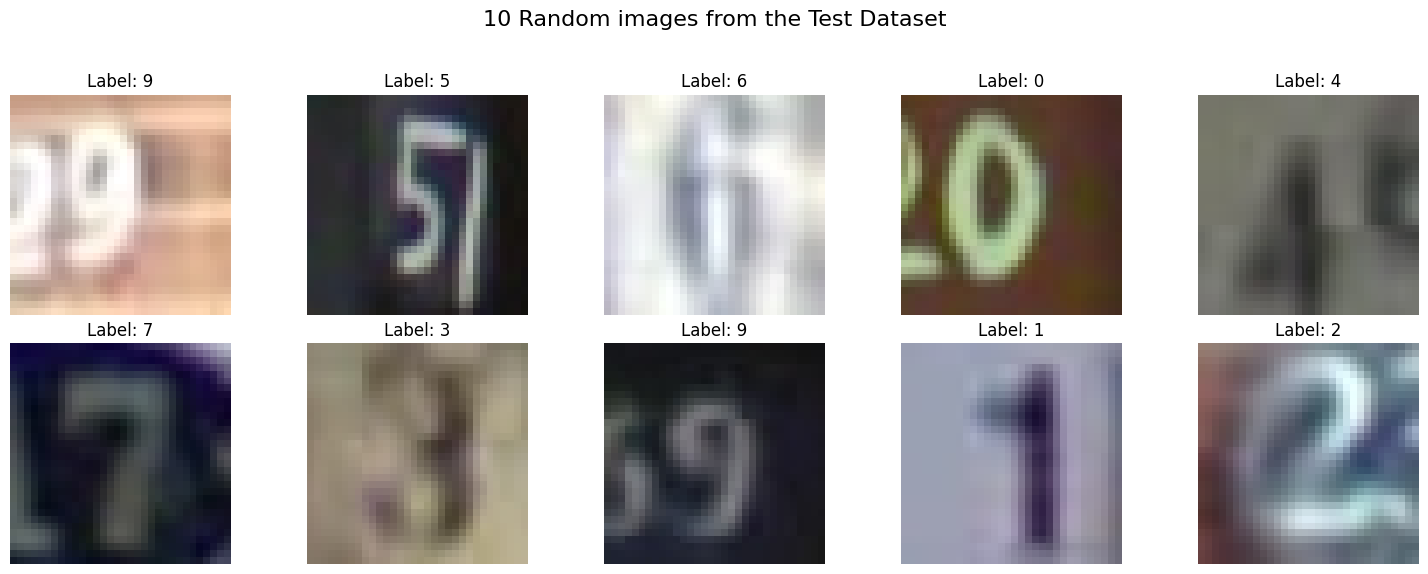

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Denormalization function
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get one batch from the test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Select up to 10 random images to display
num_images_to_show = min(10, images.shape[0])

# Generate random indices
random_indices = torch.randperm(images.shape[0])[:num_images_to_show]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    img = denormalize_image(images[idx]).numpy().transpose((1, 2, 0))
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f'Label: {labels[idx].item()}')
    plt.axis('off')
plt.suptitle('10 Random images from the Test Dataset', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

I don't see any noticable pattern -the images appear to be randomized.
I find this extremely useful for the future because now I have the code and knowledge necessary to generate images like this in the future using different datasets.

